## Re-Identification Datasets von SoccerNet 

from SoccerNet.Downloader import SoccerNetDownloader
import os
from dotenv import load_dotenv

# .env laden
load_dotenv()

password = os.getenv("SOCCERNET_PASSWORD")

if password is None:
    raise ValueError("SOCCERNET_PASSWORD not found in environment variables")

# Speicherort für SoccerNet Daten
downloader = SoccerNetDownloader(LocalDirectory="/data/manser/soccernet")

# Passwort setzen
downloader.password = password

# Re-identification dataset herunterladen
downloader.downloadDataTask(
    task="reid",
    split=["train", "valid", "test", "challenge"]
)

# optional: neue Version
downloader.downloadDataTask(
    task="reid-2023",
    split=["train", "valid", "test", "challenge"]
)

Downloading /data/manser/soccernet/reid/train.zip...: : 12.1GiB [11:10, 18.1MiB/s]                           
Downloading /data/manser/soccernet/reid/valid.zip...: : 2.35GiB [05:46, 6.80MiB/s]                          
Downloading /data/manser/soccernet/reid/test.zip...: : 2.41GiB [06:29, 6.19MiB/s]                          
Downloading /data/manser/soccernet/reid/challenge.zip...: : 1.75GiB [02:59, 9.74MiB/s] 

## Überprüfen ob Dateien erfolreich heruntergeladen wurden

In [2]:
from pathlib import Path
import json

base = Path("/data/manser/soccernet/reid")

print("Existiert:", base.exists())
print("\nTop-Level Inhalte:")
for p in sorted(base.iterdir()):
    print("-", p.name, "(dir)" if p.is_dir() else "(file)")

print("\nEin paar Dateien rekursiv:")
all_files = list(base.rglob("*"))
for p in all_files[:50]:
    print(p)

print(f"\nGesamtanzahl Eintraege: {len(all_files)}")

Existiert: True

Top-Level Inhalte:
- challenge (dir)
- test (dir)
- train (dir)
- valid (dir)

Ein paar Dateien rekursiv:


/data/manser/soccernet/reid/challenge
/data/manser/soccernet/reid/test
/data/manser/soccernet/reid/valid
/data/manser/soccernet/reid/train
/data/manser/soccernet/reid/challenge/challenge
/data/manser/soccernet/reid/challenge/challenge/.DS_Store
/data/manser/soccernet/reid/challenge/challenge/gallery
/data/manser/soccernet/reid/challenge/challenge/version.json
/data/manser/soccernet/reid/challenge/challenge/query
/data/manser/soccernet/reid/challenge/challenge/gallery/6255-315-204x158.png
/data/manser/soccernet/reid/challenge/challenge/gallery/17892-929-412x312.png
/data/manser/soccernet/reid/challenge/challenge/gallery/19761-1019-281x156.png
/data/manser/soccernet/reid/challenge/challenge/gallery/6785-339-150x85.png
/data/manser/soccernet/reid/challenge/challenge/gallery/900-49-223x106.png
/data/manser/soccernet/reid/challenge/challenge/gallery/20245-1046-642x232.png
/data/manser/soccernet/reid/challenge/challenge/gallery/13209-678-111x59.png
/data/manser/soccernet/reid/challenge/chall

Struktur:

reid/train/train/
    train_bbox_info.json
    version.json
    germany_bundesliga/
    france_ligue-1/
    spain_laliga/
    europe_uefa-champions-league/
    italy_serie-a/
    england_epl/

## Überblick LaLiga

In [3]:
base = Path("/data/manser/soccernet/reid/train/train/spain_laliga")

games = list(base.rglob("*Real Madrid*"))

print("Real Madrid Spiele gefunden:", len(games))

for g in games[:20]:
    print(g)

Real Madrid Spiele gefunden: 30
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-11-29 - 18-00 Eibar 0 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-11-21 - 20-15 Real Madrid 0 - 4 Barcelona
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-04-02 - 21-30 Barcelona 1 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-01-31 - 22-30 Real Madrid 6 - 0 Espanyol
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-03-13 - 22-30 Las Palmas 1 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-01-24 - 22-30 Betis 1 - 1 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-10-04 - 21-30 Atl. Madrid 1 - 1 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-09-23 - 22-00 Ath Bilbao 1 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-04-30 - 17-00 Real Socied

In [4]:
base = Path("/data/manser/soccernet/reid/train/train/spain_laliga")

seasons = ["2015-2016", "2016-2017"]

real_madrid_games = []

for season in seasons:
    season_path = base / season
    
    for game in season_path.iterdir():
        if "Real Madrid" in game.name:
            real_madrid_games.append((season, game.name))

print("\nReal Madrid Spiele im ReID Datensatz:\n")

for season, game in real_madrid_games:
    print(f"{season}  |  {game}")

print("\nAnzahl Spiele:", len(real_madrid_games))


Real Madrid Spiele im ReID Datensatz:

2015-2016  |  2015-11-29 - 18-00 Eibar 0 - 2 Real Madrid
2015-2016  |  2015-11-21 - 20-15 Real Madrid 0 - 4 Barcelona
2015-2016  |  2016-04-02 - 21-30 Barcelona 1 - 2 Real Madrid
2015-2016  |  2016-01-31 - 22-30 Real Madrid 6 - 0 Espanyol
2015-2016  |  2016-03-13 - 22-30 Las Palmas 1 - 2 Real Madrid
2015-2016  |  2016-01-24 - 22-30 Betis 1 - 1 Real Madrid
2015-2016  |  2015-10-04 - 21-30 Atl. Madrid 1 - 1 Real Madrid
2015-2016  |  2015-09-23 - 22-00 Ath Bilbao 1 - 2 Real Madrid
2015-2016  |  2016-04-30 - 17-00 Real Sociedad 0 - 1 Real Madrid
2015-2016  |  2016-03-05 - 18-00 Real Madrid 7 - 1 Celta Vigo
2015-2016  |  2015-09-26 - 19-15 Real Madrid 0 - 0 Malaga
2015-2016  |  2016-04-20 - 23-00 Real Madrid 3 - 0 Villarreal
2016-2017  |  2016-10-15 - 21-45 Betis 1 - 6 Real Madrid
2016-2017  |  2017-04-15 - 17-15 Gijon 2 - 3 Real Madrid
2016-2017  |  2017-05-06 - 21-45 Granada CF 0 - 4 Real Madrid
2016-2017  |  2017-03-18 - 18-15 Ath Bilbao 1 - 2 Real

## Beispielbild ansehen

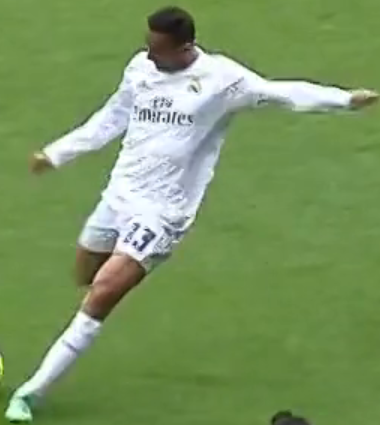

In [5]:
from PIL import Image
from IPython.display import display

img_path = "/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-03-05 - 18-00 Real Madrid 7 - 1 Celta Vigo/0/206941-7783-135782-20495-Player_team_left-13-0fbr000_001cd2cb0002-425x380.png"

img = Image.open(img_path)
display(img)

Bounding Box Crops

/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-03-05 - 18-00 Real Madrid 7 - 1 Celta Vigo/0/206941-7783-135782-20495-Player_team_left-13-0fbr000_001cd2cb0002-425x380.png

In [6]:
path = Path("/data/manser/soccernet/reid/train/train/train_bbox_info.json")

with open(path) as f:
    data = json.load(f)

print(type(data))
print(len(data))

# erste Einträge anzeigen
for i, (k,v) in enumerate(data.items()):
    print(k)
    print(v)
    if i == 3:
        break

<class 'dict'>
248234
0
{'bbox_idx': 0, 'action_idx': 0, 'person_uid': 0, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': 'None', 'UAI': '000r000_004597cb000d', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/0', 'height': 74, 'width': 32}
1
{'bbox_idx': 1, 'action_idx': 0, 'person_uid': 1, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': 'None', 'UAI': '000r000_004597cb000e', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/0', 'height': 51, 'width': 20}
2
{'bbox_idx': 2, 'action_idx': 0, 'person_uid': 2, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': 'b', 'UAI': '000r000_004597cb000f', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/0', 'height': 63, 'width': 24}
3
{'bbox_idx': 3, 'action_idx': 0, 'person_uid': 3, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': '2', 'UAI': '000r000_004597cb0010', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley

{
 'bbox_idx': 0,
 'action_idx': 0,
 'person_uid': 0,
 'frame_idx': 0,
 'clazz': 'Player_team_left',
 'id': 'None',
 'UAI': '000r000_004597cb000d',
 'relative_path': 'england_epl/.../0',
 'height': 74,
 'width': 32
}

In [7]:
from collections import Counter

uids = [v["person_uid"] for v in data.values()]
Counter(uids).most_common(10)

[(8607, 9),
 (37652, 9),
 (37653, 9),
 (42940, 9),
 (42942, 9),
 (73713, 9),
 (73716, 9),
 (84776, 9),
 (84785, 9),
 (88793, 9)]

## Alle Real Madrid Einträge finden

In [8]:
from pathlib import Path
import json

path = Path("/data/manser/soccernet/reid/train/train/train_bbox_info.json")

with open(path) as f:
    data = json.load(f)

# Alle Einträge mit "Real Madrid"
rm_entries = [
    v for v in data.values()
    if "Real Madrid" in v["relative_path"]
]

print("Anzahl Einträge mit Real Madrid:", len(rm_entries))

# Beispiel anzeigen
for e in rm_entries[:5]:
    print(e["relative_path"])

Anzahl Einträge mit Real Madrid: 34434
europe_uefa-champions-league/2014-2015/2014-12-09 - 22-45 Real Madrid 4 - 0 Ludogorets/0
europe_uefa-champions-league/2014-2015/2014-12-09 - 22-45 Real Madrid 4 - 0 Ludogorets/0
europe_uefa-champions-league/2014-2015/2014-12-09 - 22-45 Real Madrid 4 - 0 Ludogorets/0
europe_uefa-champions-league/2014-2015/2014-12-09 - 22-45 Real Madrid 4 - 0 Ludogorets/0
europe_uefa-champions-league/2014-2015/2014-12-09 - 22-45 Real Madrid 4 - 0 Ludogorets/0


In [9]:
games = set()

for v in data.values():
    if "Real Madrid" in v["relative_path"]:
        # Spielpfad ohne Frame-Ordner extrahieren
        game_path = v["relative_path"].rsplit("/", 1)[0]
        games.add(game_path)

print("Anzahl Real Madrid Spiele:", len(games))

for g in sorted(games):
    print(g)

Anzahl Real Madrid Spiele: 36
europe_uefa-champions-league/2014-2015/2014-12-09 - 22-45 Real Madrid 4 - 0 Ludogorets
europe_uefa-champions-league/2014-2015/2015-02-18 - 22-45 Schalke 0 - 2 Real Madrid
europe_uefa-champions-league/2014-2015/2015-04-14 - 21-45 Atl. Madrid 0 - 0 Real Madrid
europe_uefa-champions-league/2015-2016/2015-09-15 - 21-45 Real Madrid 4 - 0 Shakhtar Donetsk
europe_uefa-champions-league/2016-2017/2017-03-07 - 22-45 Napoli 1 - 3 Real Madrid
europe_uefa-champions-league/2016-2017/2017-04-18 - 21-45 Real Madrid 4 - 2 Bayern Munich
spain_laliga/2014-2015/2015-05-09 - 21-00 Real Madrid 2 - 2 Valencia
spain_laliga/2015-2016/2015-09-23 - 22-00 Ath Bilbao 1 - 2 Real Madrid
spain_laliga/2015-2016/2015-09-26 - 19-15 Real Madrid 0 - 0 Malaga
spain_laliga/2015-2016/2015-10-04 - 21-30 Atl. Madrid 1 - 1 Real Madrid
spain_laliga/2015-2016/2015-11-21 - 20-15 Real Madrid 0 - 4 Barcelona
spain_laliga/2015-2016/2015-11-29 - 18-00 Eibar 0 - 2 Real Madrid
spain_laliga/2015-2016/2016-01

In [10]:
malaga_games = [g for g in games if "Malaga" in g]

for g in malaga_games:
    print(g)

spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid
spain_laliga/2015-2016/2015-09-26 - 19-15 Real Madrid 0 - 0 Malaga


## Ein Test-Spiel analysieren
spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid

In [11]:
path = Path("/data/manser/soccernet/reid/train/train/train_bbox_info.json")

with open(path) as f:
    data = json.load(f)

game_path = "spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid"

# Nur dieses Spiel
game_entries = [
    v for v in data.values()
    if game_path in v["relative_path"]
]

print("Anzahl Bounding Boxes:", len(game_entries))

Anzahl Bounding Boxes: 844


In [12]:
from collections import defaultdict, Counter

player_data = defaultdict(lambda: {
    "ids": [],
    "teams": [],
    "frames": set()
})

for e in game_entries:
    uid = e["person_uid"]
    
    player_data[uid]["ids"].append(e["id"])
    player_data[uid]["teams"].append(e["clazz"])
    player_data[uid]["frames"].add(e["frame_idx"])

summary = []

for uid, info in player_data.items():
    id_counter = Counter(info["ids"])
    team_counter = Counter(info["teams"])
    
    summary.append({
        "person_uid": uid,
        "most_common_id": id_counter.most_common(1)[0][0],
        "team": team_counter.most_common(1)[0][0],
        "num_frames": len(info["frames"]),
        "num_boxes": len(info["ids"])
    })

# Sortieren nach Aktivität
summary = sorted(summary, key=lambda x: x["num_boxes"], reverse=True)

# Ausgabe
for s in summary[:20]:
    print(
        f"UID {s['person_uid']:>3} | "
        f"ID: {s['most_common_id']:>4} | "
        f"{s['team']:>20} | "
        f"Frames: {s['num_frames']:>3} | "
        f"Boxes: {s['num_boxes']:>4}"
    )

UID 160920 | ID:    7 |    Player_team_right | Frames:   6 | Boxes:    6
UID 161021 | ID:   22 |    Player_team_right | Frames:   5 | Boxes:    5
UID 161214 | ID:    9 |     Player_team_left | Frames:   5 | Boxes:    5
UID 160921 | ID:    1 | Goalkeeper_team_left | Frames:   4 | Boxes:    4
UID 161019 | ID:    b |     Player_team_left | Frames:   4 | Boxes:    4
UID 161020 | ID:   19 |    Player_team_right | Frames:   4 | Boxes:    4
UID 161215 | ID:    5 |     Player_team_left | Frames:   4 | Boxes:    4
UID 161217 | ID:    4 |     Player_team_left | Frames:   4 | Boxes:    4
UID 161218 | ID:    4 |    Player_team_right | Frames:   4 | Boxes:    4
UID 161220 | ID:    1 | Goalkeeper_team_right | Frames:   4 | Boxes:    4
UID 161221 | ID:   15 |    Player_team_right | Frames:   4 | Boxes:    4
UID 161222 | ID:   31 |    Player_team_right | Frames:   4 | Boxes:    4
UID 160924 | ID:    4 |     Player_team_left | Frames:   3 | Boxes:    3
UID 161022 | ID:    4 |     Player_team_left | Fra

In [ ]:
from PIL import Image
from IPython.display import display
import random
from pathlib import Path

base_path = Path("/data/manser/soccernet/reid/train/train")

def show_samples(uid, game_entries, n=5):
    samples = [e for e in game_entries if e["person_uid"] == uid]
    
    print(f"UID {uid} -> {len(samples)} Samples\n")
    
    for e in random.sample(samples, min(n, len(samples))):
        img_path = base_path / e["relative_path"] / (
            f"{e['bbox_idx']}-"
            f"{e['height']}x{e['width']}.png"
        )
        
        # Falls Pfad nicht exakt passt -> fallback: suche Datei
        if not img_path.exists():
            folder = base_path / e["relative_path"]
            files = list(folder.glob(f"{e['bbox_idx']}*.png"))
            if files:
                img_path = files[0]
        
        if img_path.exists():
            print("Path:", img_path)
            display(Image.open(img_path))

UID 160920 -> 6 Samples

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/1/247423-9161-160920-24315-Player_team_right-7-12br001_404f7dbb0001-782x595.png


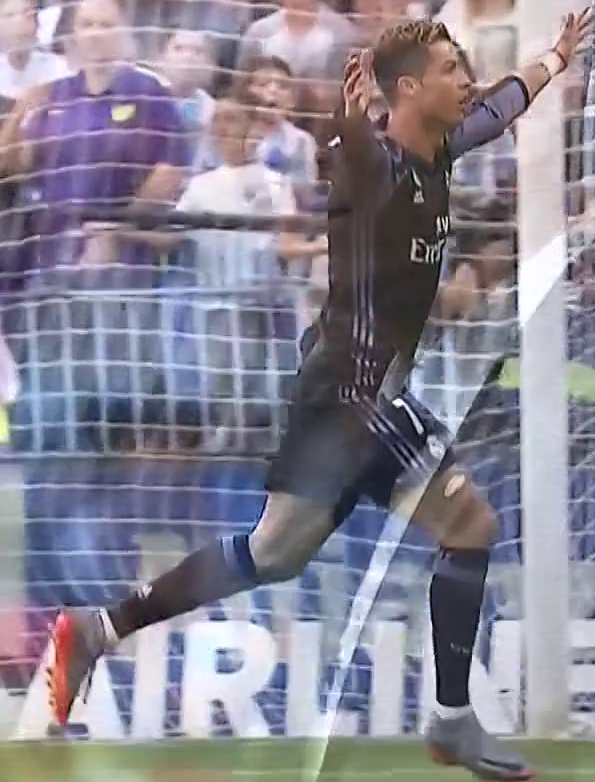

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/1/247450-9161-160920-24320-Player_team_right-7-12ba00001017cd0b0006-125x113.png


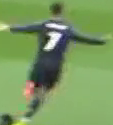

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/1/247420-9161-160920-24314-Player_team_right-7-12br001_5021b77b0002-166x137.png


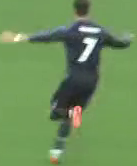

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/1/247426-9161-160920-24318-Player_team_right-7-12br001_104b58eb0000-96x76.png


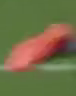

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/1/247424-9161-160920-24316-Player_team_right-7-12br001_304f706b0001-782x527.png


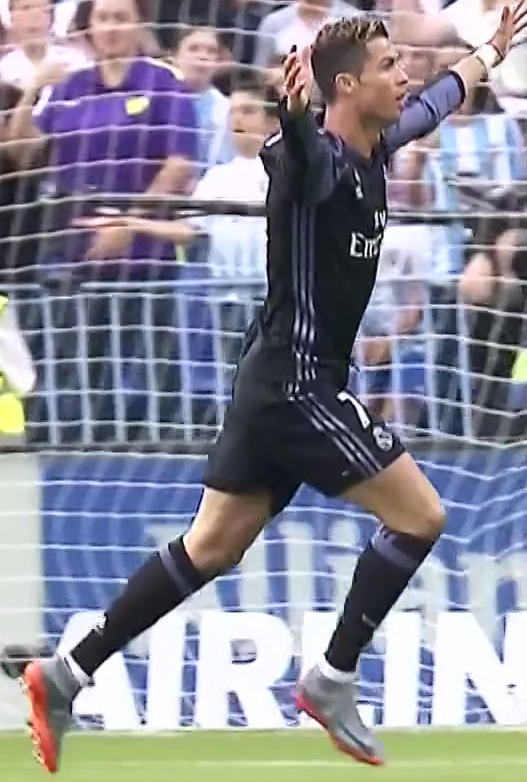

In [14]:
show_samples(160920, game_entries)

UID 161021 -> 5 Samples

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/7/247601-9167-161021-24334-Player_team_right-22-12br007_012e3dab0011-111x35.png


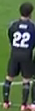

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/7/247562-9167-161021-24331-Player_team_right-22-12br007_3132c80b0003-421x133.png


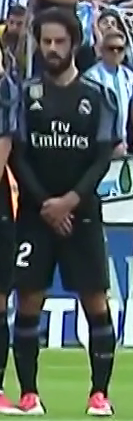

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/7/247575-9167-161021-24332-Player_team_right-22-12br007_212fa2eb000d-133x50.png


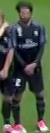

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/7/247615-9167-161021-24335-Player_team_right-22-12ba000071268dcb000a-96x20.png


Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/7/247584-9167-161021-24333-Player_team_right-22-12br007_1130f25b0002-897x273.png


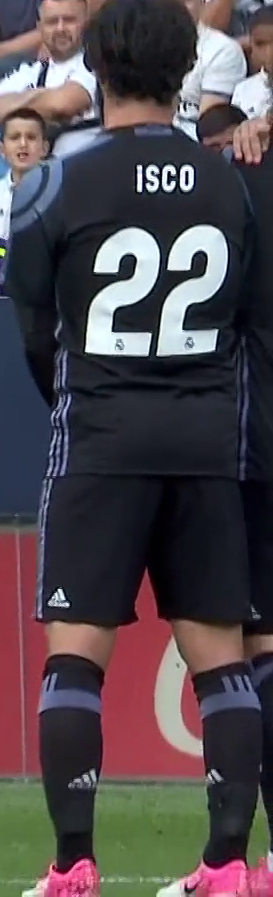

In [15]:
show_samples(161021, game_entries)

## UIDS - Spieler Mapping

Spieler:
- 1: keylor navas
- 4: Sergio Ramos
- 5: Raphael Varane
- 12: Marcelo
- 23: Danilo
- 7: Christiano Ronaldo
- 14: Casemiro
- 22: Isco
- 8: Toni Kroos
- 19: Luka Modric
- 9: Karim Benzema


UID 161020: Ronaldo
UID 161021: Isco

UID 161222 -> 4 Samples

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/17/247920-9177-161222-24360-Player_team_right-31-12ba0001708d2a3b0008-118x49.png


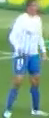

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/17/247908-9177-161222-24359-Player_team_right-31-12br017_009ad41b0008-209x102.png


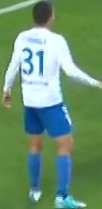

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/17/247887-9177-161222-24357-Player_team_right-31-12br017_2110becb0002-778x282.png


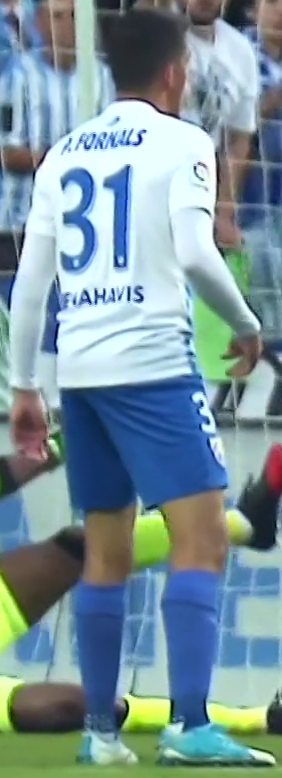

Path: /data/manser/soccernet/reid/train/train/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/17/247897-9177-161222-24358-Player_team_right-31-12br017_10d2eb7b0009-253x81.png


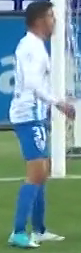

In [17]:
show_samples(161222, game_entries)

## UIDs checken

Einträge für Spiel: 844

UID: 160920
Samples: 6
IDs: ['7', '7', '7', '7', '7', '7']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right']


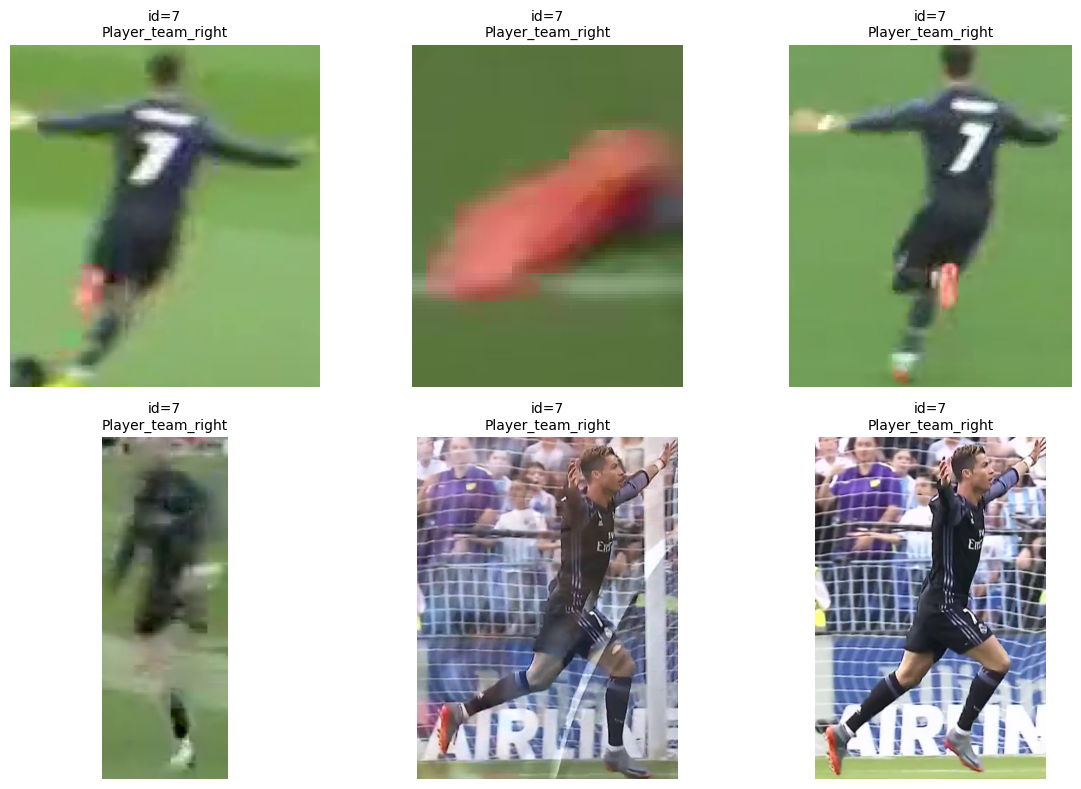


UID: 161021
Samples: 5
IDs: ['22', '22', '22', '22', '22']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right']


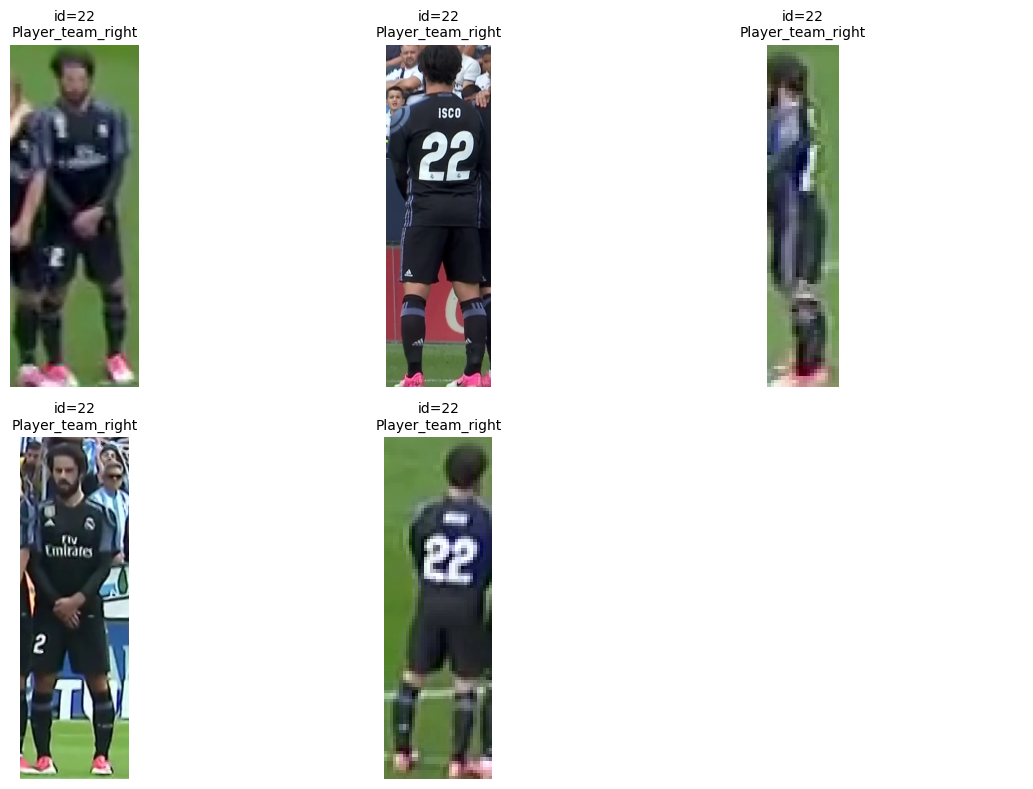


UID: 161214
Samples: 5
IDs: ['9', '9', '9', '9', '9']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left', 'Player_team_left', 'Player_team_left']


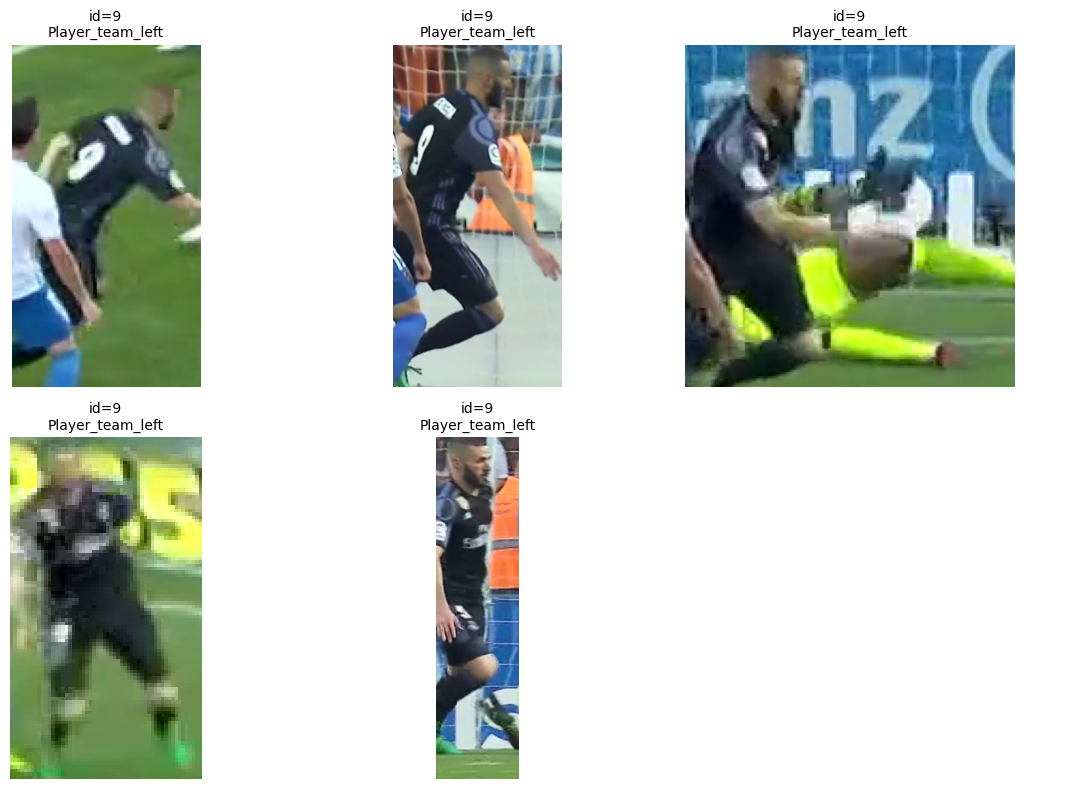


UID: 160921
Samples: 4
IDs: ['1', '1', '1', '1']
Teams: ['Goalkeeper_team_left', 'Goalkeeper_team_left', 'Goalkeeper_team_left', 'Goalkeeper_team_left']


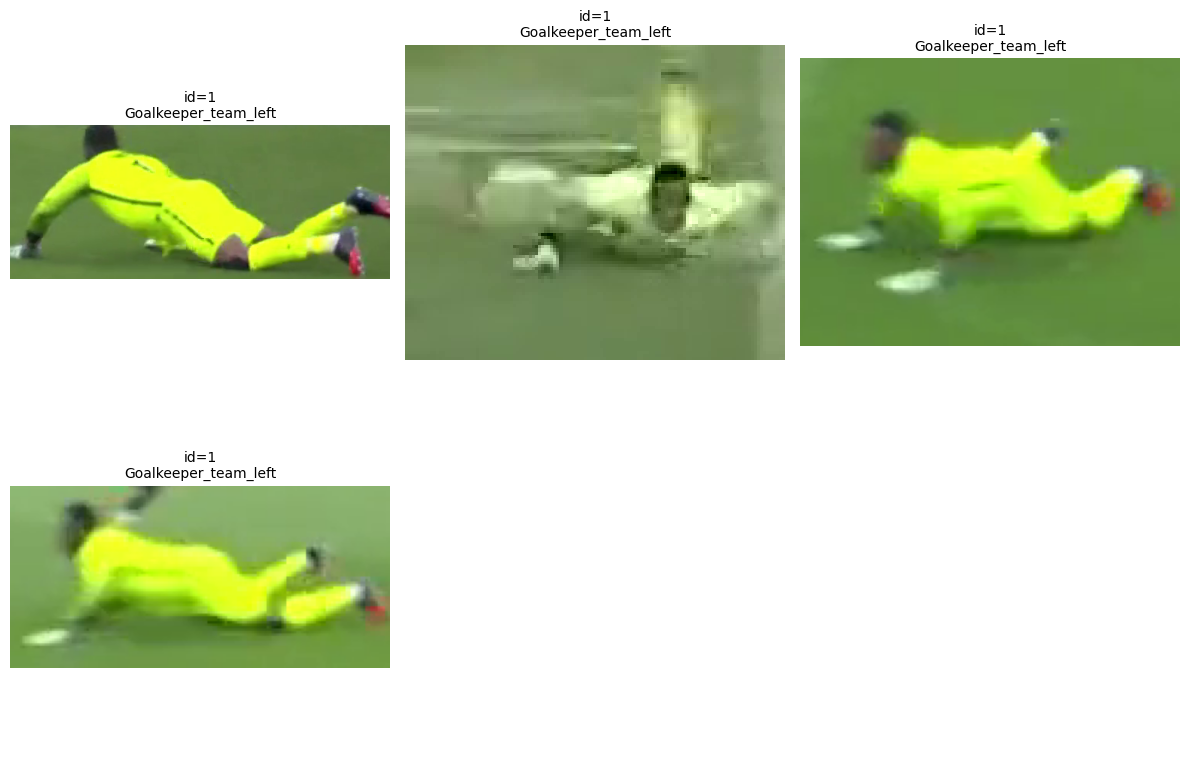


UID: 161019
Samples: 4
IDs: ['b', 'b', 'b', 'b']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left', 'Player_team_left']


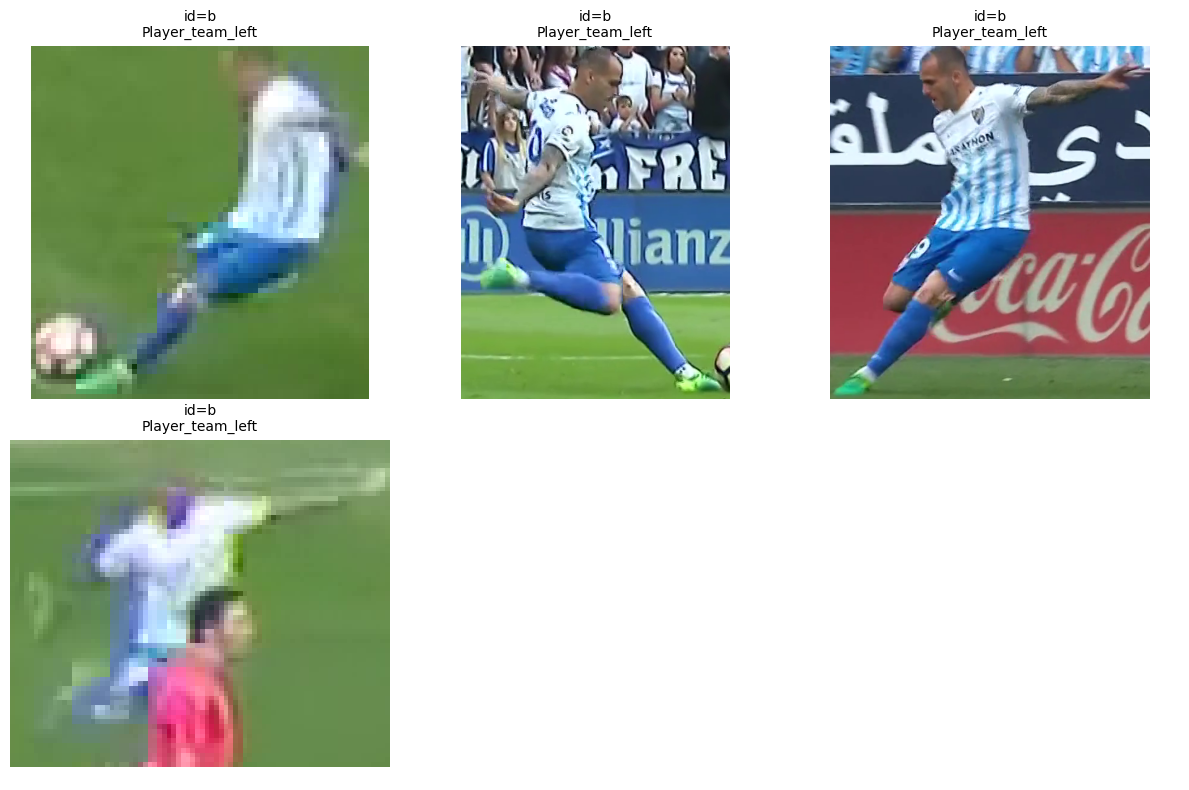


UID: 161020
Samples: 4
IDs: ['19', '19', '19', '19']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right']


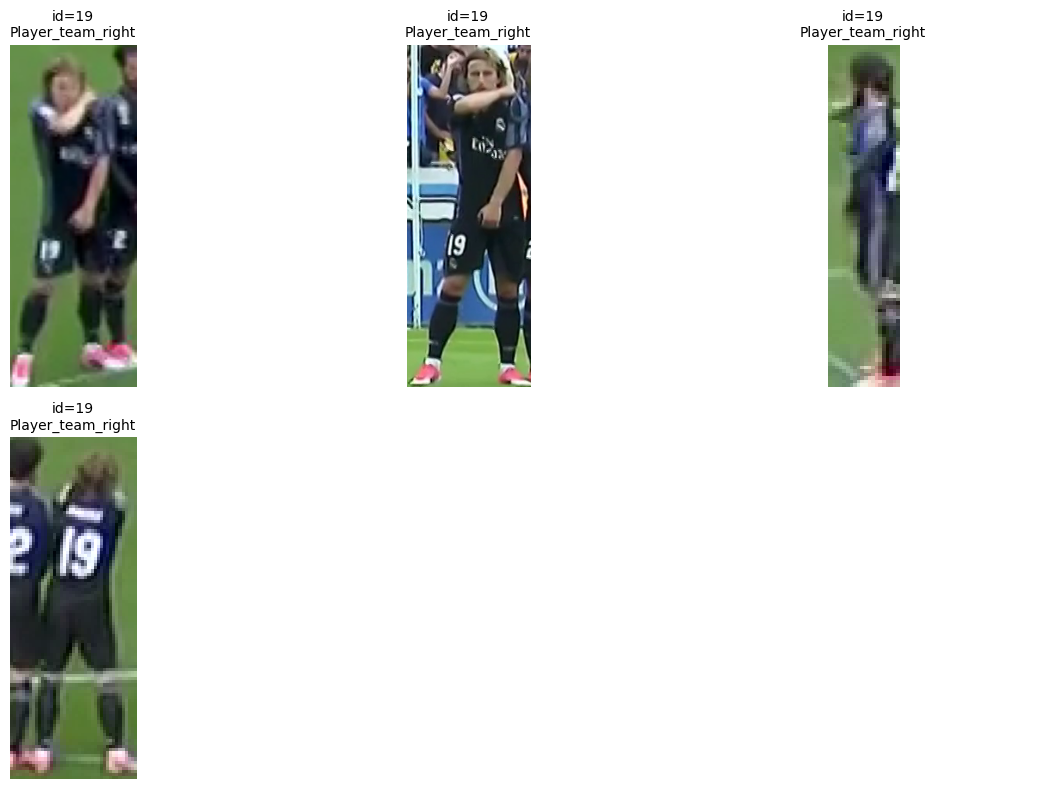


UID: 161215
Samples: 4
IDs: ['5', '5', '5', '5']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left', 'Player_team_left']


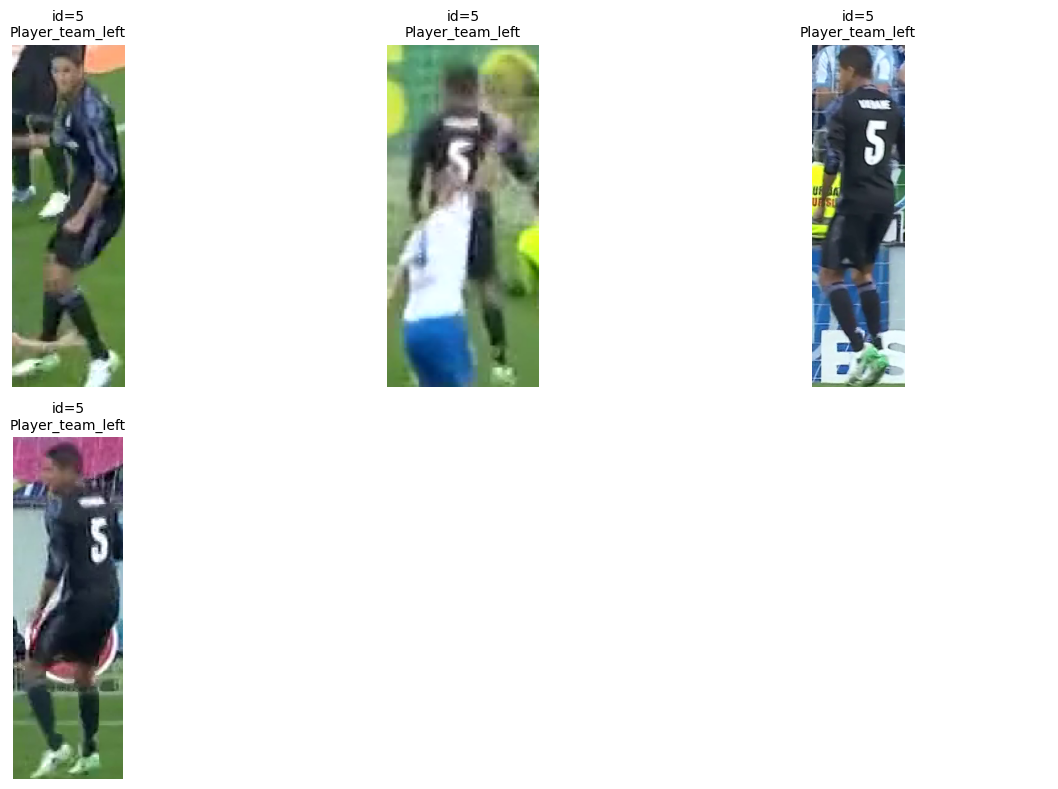


UID: 161217
Samples: 4
IDs: ['4', '4', '4', '4']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left', 'Player_team_left']


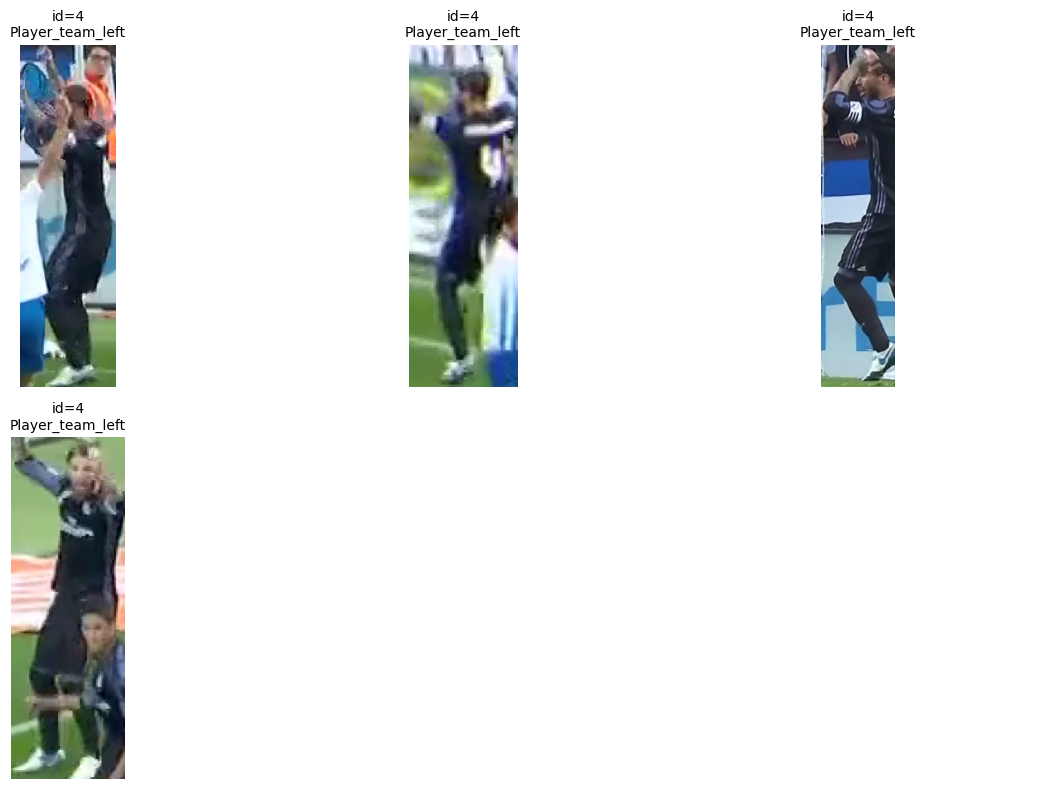


UID: 161218
Samples: 4
IDs: ['4', '4', '4', '4']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right']


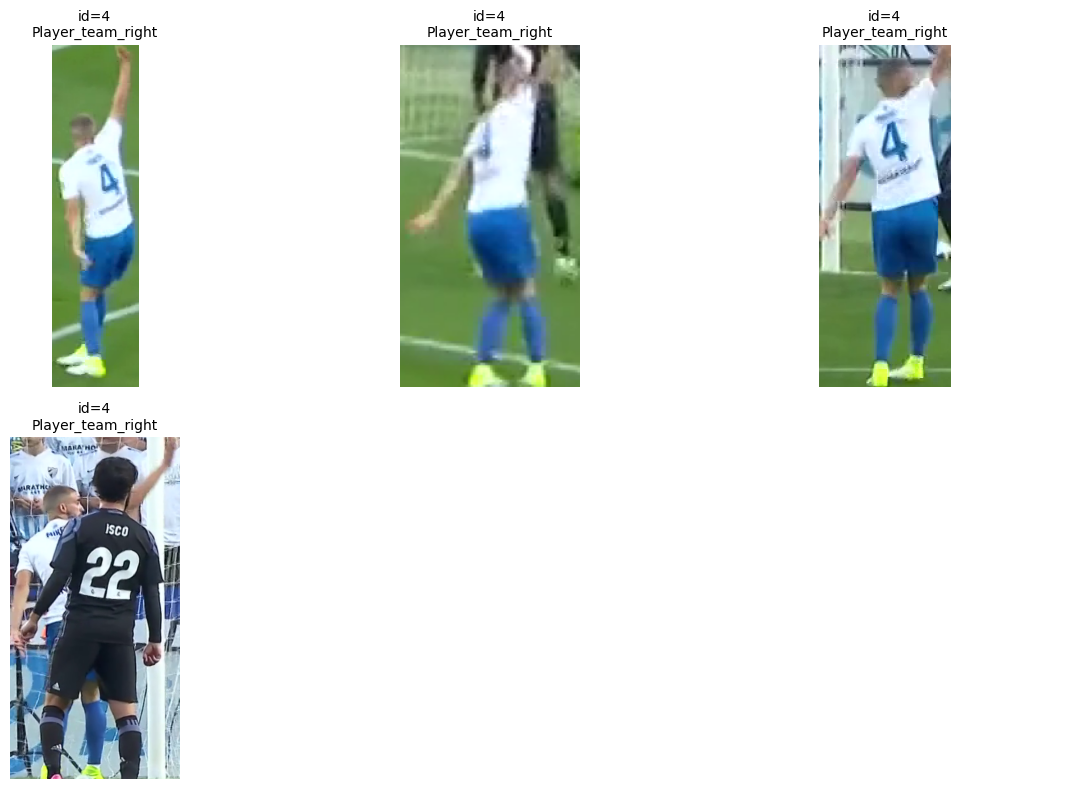


UID: 161220
Samples: 4
IDs: ['1', '1', '1', '1']
Teams: ['Goalkeeper_team_right', 'Goalkeeper_team_right', 'Goalkeeper_team_right', 'Goalkeeper_team_right']


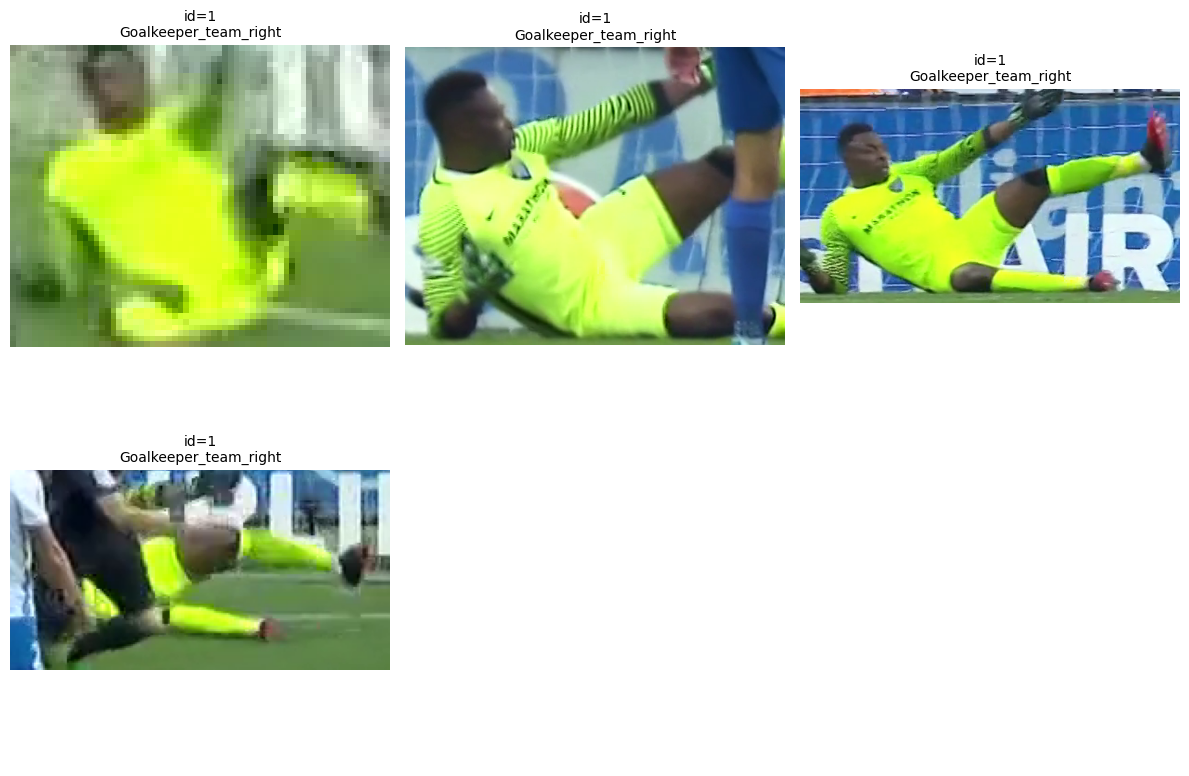


UID: 161221
Samples: 4
IDs: ['15', '15', '15', '15']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right']


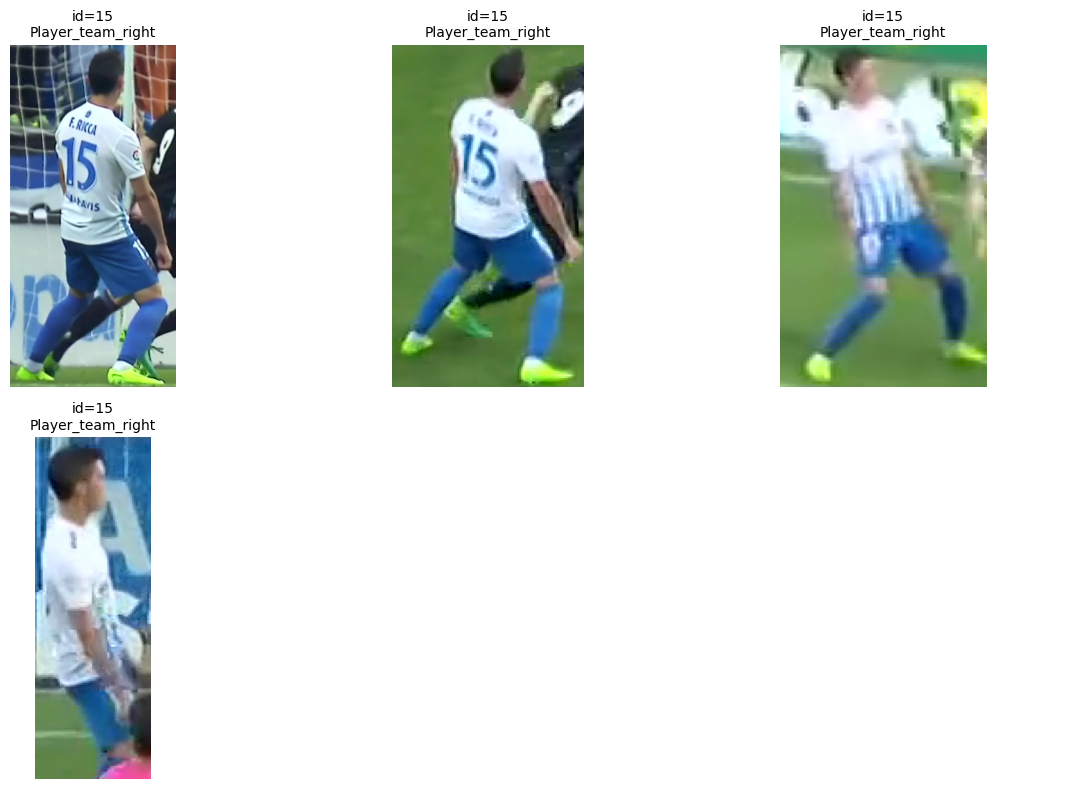


UID: 161222
Samples: 4
IDs: ['31', '31', '31', '31']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right', 'Player_team_right']


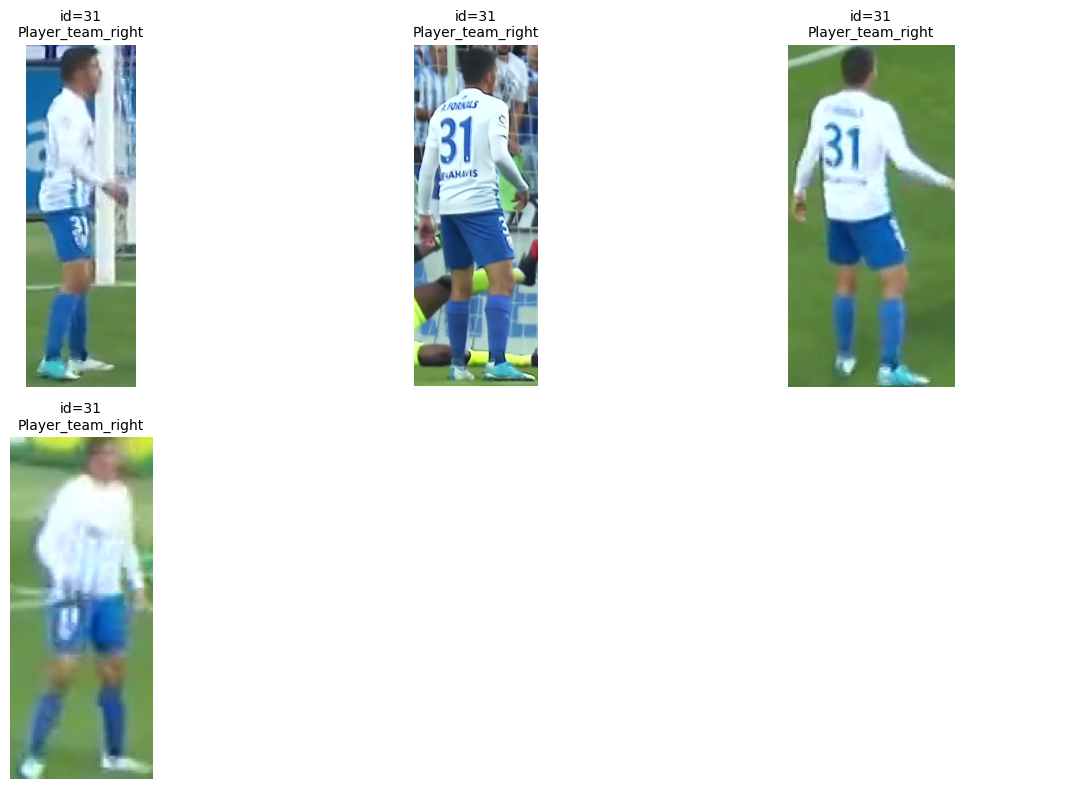


UID: 160924
Samples: 3
IDs: ['4', '4', '4']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left']


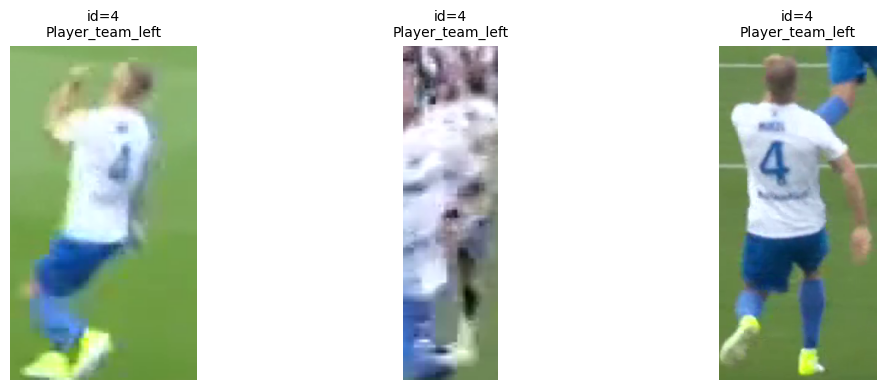


UID: 161022
Samples: 3
IDs: ['4', '4', '4']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left']


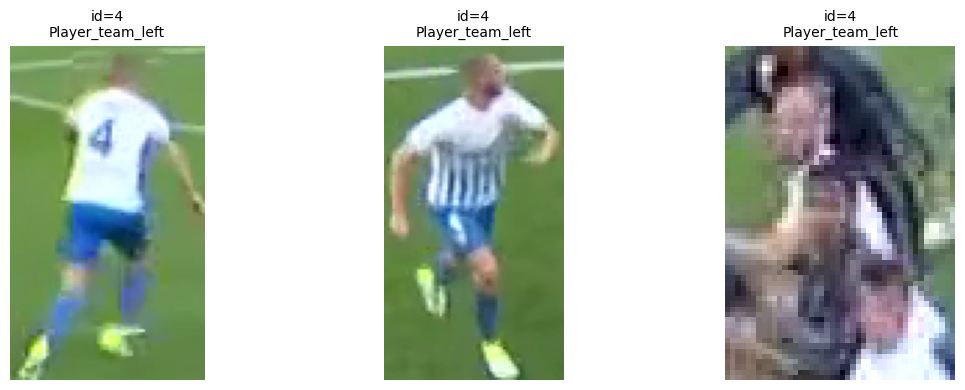


UID: 161023
Samples: 3
IDs: ['15', '15', '15']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left']


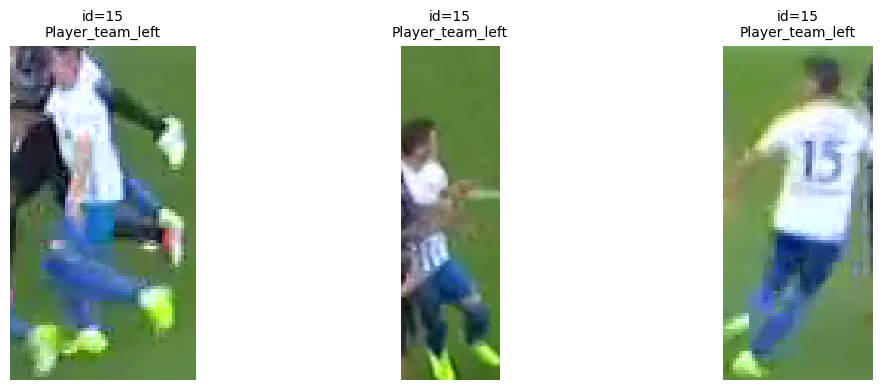


UID: 161024
Samples: 3
IDs: ['21', '21', '21']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left']


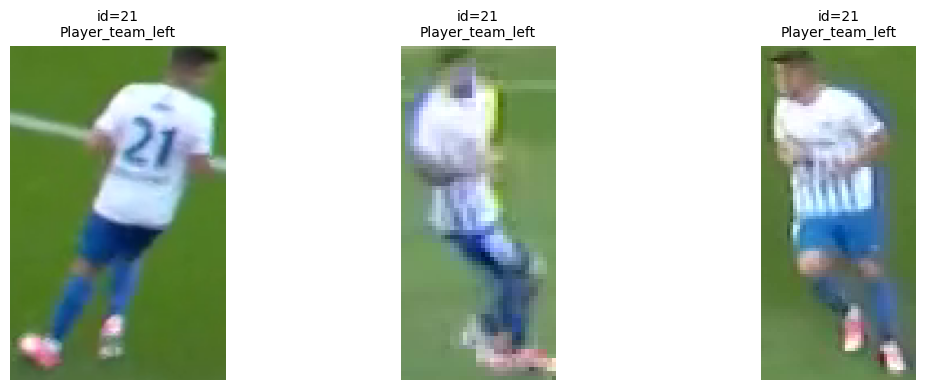


UID: 161028
Samples: 3
IDs: ['24', '24', '24']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left']


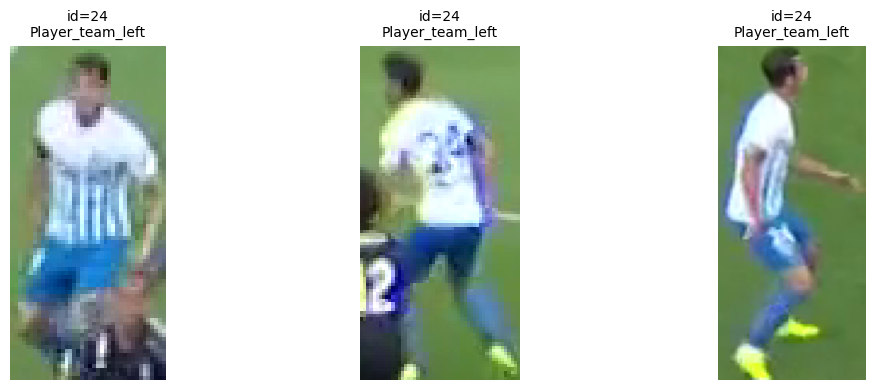


UID: 161029
Samples: 3
IDs: ['6', '6', '6']
Teams: ['Player_team_left', 'Player_team_left', 'Player_team_left']


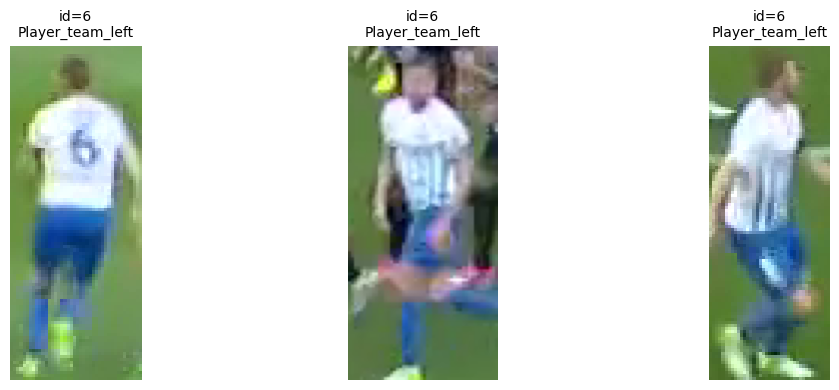


UID: 161030
Samples: 3
IDs: ['23', '23', '23']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right']


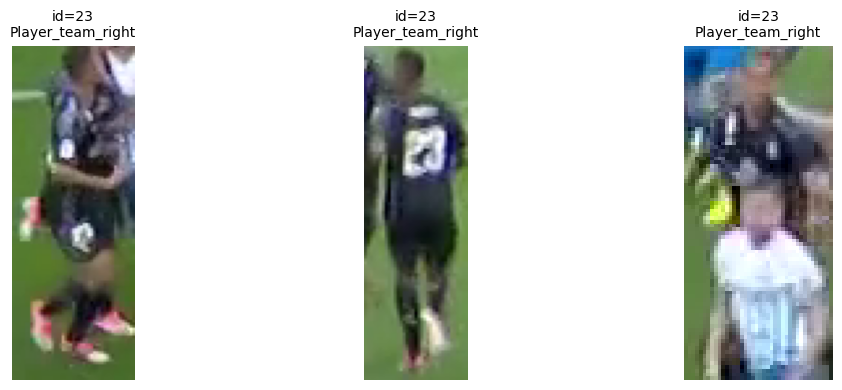


UID: 161031
Samples: 3
IDs: ['14', '14', '14']
Teams: ['Player_team_right', 'Player_team_right', 'Player_team_right']


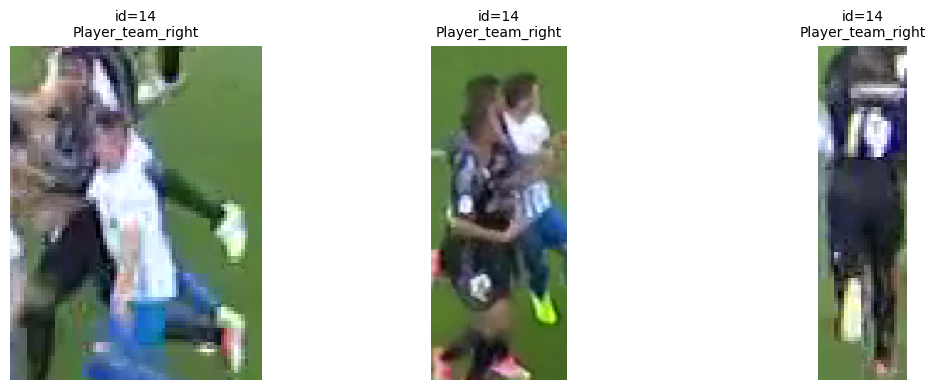

In [18]:
from pathlib import Path
import json
import random
import math

from PIL import Image
import matplotlib.pyplot as plt


# ==================================================
# 1) Setup
# ==================================================
base_path = Path("/data/manser/soccernet/reid/train/train")

game_path = "spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid"

uids_to_check = [
    160920, 161021, 161214, 160921, 161019,
    161020, 161215, 161217, 161218, 161220,
    161221, 161222, 160924, 161022, 161023,
    161024, 161028, 161029, 161030, 161031
]


# ==================================================
# 2) Daten laden
# ==================================================
bbox_path = base_path / "train_bbox_info.json"

with open(bbox_path, "r") as f:
    data = json.load(f)

game_entries = [
    v for v in data.values()
    if game_path in v["relative_path"]
]

print("Einträge für Spiel:", len(game_entries))


# ==================================================
# 3) Hilfsfunktionen
# ==================================================
def get_entries_for_uid(uid):
    return [e for e in game_entries if e["person_uid"] == uid]


def find_image(entry):
    folder = base_path / entry["relative_path"]
    bbox_idx = str(entry["bbox_idx"])

    # Hauptfall
    files = list(folder.glob(f"{bbox_idx}-*.png"))
    if files:
        return files[0]

    # Fallback
    files = list(folder.glob(f"{bbox_idx}*.png"))
    if files:
        return files[0]

    return None


def show_uid(uid, max_images=6):
    samples = get_entries_for_uid(uid)

    if not samples:
        print(f"\nUID {uid}: KEINE DATEN")
        return

    # sortiere nach frame
    samples = sorted(samples, key=lambda x: x["frame_idx"])

    # zufällig auswählen
    samples = random.sample(samples, min(max_images, len(samples)))

    print("\n" + "="*60)
    print(f"UID: {uid}")
    print(f"Samples: {len(samples)}")

    # Meta Info anzeigen
    ids = [s["id"] for s in samples]
    teams = [s["clazz"] for s in samples]

    print("IDs:", ids)
    print("Teams:", teams)

    # Bilder anzeigen
    cols = 3
    rows = math.ceil(len(samples) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, e in zip(axes, samples):
        img_path = find_image(e)

        if img_path is not None and img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)

            title = f"id={e['id']}\n{e['clazz']}"
            ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


# ==================================================
# 4) Alle UIDs durchgehen
# ==================================================
for uid in uids_to_check:
    show_uid(uid)

## Finales Mapping

In [19]:
uid_to_player_info = {
    160920: {"player": "Cristiano Ronaldo", "jersey": 7,  "team": "Real Madrid"},
    161021: {"player": "Isco",              "jersey": 22, "team": "Real Madrid"},
    161214: {"player": "Karim Benzema",     "jersey": 9,  "team": "Real Madrid"},
    161020: {"player": "Luka Modric",       "jersey": 19, "team": "Real Madrid"},
    161215: {"player": "Raphael Varane",    "jersey": 5,  "team": "Real Madrid"},
    161217: {"player": "Sergio Ramos",      "jersey": 4,  "team": "Real Madrid"},
    161030: {"player": "Danilo",            "jersey": 23, "team": "Real Madrid"},
    161031: {"player": "Casemiro",          "jersey": 14, "team": "Real Madrid"},
}

In [20]:
uid_to_status = {
    160921: "not_real_madrid",
    161019: "not_real_madrid",
    161218: "not_real_madrid",
    161220: "not_real_madrid",
    161221: "not_real_madrid",
    161222: "not_real_madrid",
    160924: "not_real_madrid",
    161022: "not_real_madrid",
    161023: "not_real_madrid",
    161024: "not_real_madrid",
    161028: "not_real_madrid",
    161029: "not_real_madrid",
}